# Classification DPE — Performant / Passable / Energivore
## Pipeline final — Comparaison des meilleurs modeles de chaque famille

**Entree :** `data_for_processing_final.xlsx` — la colonne `etiquette_dpe` contient directement
les 3 groupes cibles.

**Objectif :** ce notebook reprend le meilleur modele de chacune des 4 familles testees dans les
notebooks precedents du pipeline, et les reoptimise avec un budget Optuna plus important
(`N_TRIALS = 50`, contre 25 precedemment), sur un preprocesseur strictement partage, afin
d'obtenir une comparaison finale equitable et de designer un modele de reference pour le projet.

**Modeles retenus, avec leur F1 macro de reference (notebooks precedents, N_TRIALS=25) :**

| Famille                | Modele retenu        | F1 macro (test) |
|-------------------------|-----------------------|-----------------|
| Regression Logistique  | Elastic Net           | 0.726           |
| SVM                     | SVM (noyau RBF)       | 0.727           |
| Arbre / Random Forest  | Random Forest         | 0.788           |
| Boosting                | Gradient Boosting     | 0.780           |

**Changements par rapport aux notebooks individuels :**
- **Encodage ordinal explicite** (`qualite_isolation_*`, `classe_inertie_batiment`,
  `periode_construction`) applique ici aux 4 modeles, y compris Regression Logistique et SVM
  qui ne l'avaient pas dans leurs notebooks d'origine (ajoute en cours de pipeline pour le
  Boosting et l'Arbre/Random Forest).
- **Preprocesseur unique partage par les 4 modeles** (`RobustScaler` + encodage ordinal +
  `TargetEncoder`), y compris pour Random Forest et Gradient Boosting qui n'ont pas besoin de
  mise a l'echelle : conserve par souci de simplicite et de stricte comparabilite, sans impact
  negatif sur ces deux modeles (une transformation monotone ne change pas la structure d'un
  arbre).
- **Sous-echantillon partage uniquement pour le SVM** (`N_SAMPLE = 8000`, taille deja utilisee
  dans son notebook dedie) : seul ce modele a un cout algorithmique qui impose cette contrainte.
  Les 3 autres modeles (Elastic Net, Random Forest, Gradient Boosting) sont optimises et
  entraines sur l'**integralite du train set**, comme dans leurs notebooks individuels d'origine,
  pour ne pas leur faire perdre artificiellement de la donnee utile.
- **N_TRIALS = 50** pour chacun des 4 modeles (contre 25 dans les notebooks individuels).

**Pas de calibration** des probabilites dans ce notebook (volontairement laissee de cote,
coherent avec le reste du pipeline).

**Plan du notebook :**
1. Imports et configuration
2. Chargement des donnees
3. Pretraitement (avec encodage ordinal)
4. Split train / test et sous-echantillon partage
5. Pipeline et preprocesseur partage
6. Regression Logistique (Elastic Net)
7. SVM (noyau RBF)
8. Random Forest
9. Gradient Boosting
10. Comparaison finale des 4 modeles
11. Evaluation detaillee du modele retenu
   - 11.1 Courbe d'apprentissage et diagnostic de surapprentissage
   - 11.2 Matrice de confusion
   - 11.3 Rapport de classification
   - 11.4 Courbes ROC et Precision-Rappel
12. Conclusion


## 1. Imports et configuration

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from category_encoders import TargetEncoder

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline


####################################### A PARAMETRER ################################

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Les 3 groupes metier, directement disponibles dans la colonne cible
TARGET = "etiquette_dpe"
GROUPS = ["Performant", "Passable", "Energivore"]

GROUP_COLORS = {
    "Performant": "#00923F",
    "Passable":   "#F2C12B",
    "Energivore": "#E6442E",
}

N_TRIALS = 50   # budget Optuna par modele (contre 25 dans les notebooks individuels)
N_SAMPLE = 8000  # sous-echantillon partage par les 4 modeles (contrainte du SVM a noyau)

print("Imports OK")
print(f"  Cible : '{TARGET}' -> {GROUPS}")
print(f"  N_TRIALS = {N_TRIALS}  |  N_SAMPLE = {N_SAMPLE}")


Imports OK
  Cible : 'etiquette_dpe' -> ['Performant', 'Passable', 'Energivore']
  N_TRIALS = 50  |  N_SAMPLE = 8000


## 2. Chargement des donnees

In [24]:
FILE_PATH = "resources/data_for_processing_final.xlsx"

df = pd.read_excel(FILE_PATH)
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Valeurs manquantes totales : {df.isnull().sum().sum()}")

vals = df[TARGET].unique()
print(f"\nValeurs uniques de '{TARGET}' : {sorted(vals)}")

print("\nDistribution de la cible :")
vc = df[TARGET].value_counts().reindex(GROUPS)
for grp, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {grp:<12} {cnt:6,}  ({pct:5.1f}%)  {bar}")

print(f"\nRatio de desequilibre : {vc.max() / vc.min():.1f}:1")


Dataset : 55,357 lignes x 25 colonnes
Valeurs manquantes totales : 9

Valeurs uniques de 'etiquette_dpe' : ['Energivore', 'Passable', 'Performant']

Distribution de la cible :
  Performant    2,303  (  4.2%)  ##
  Passable     39,557  ( 71.5%)  ###################################
  Energivore   13,497  ( 24.4%)  ############

Ratio de desequilibre : 17.2:1


## 3. Pretraitement des donnees

In [25]:
def suppress_quasi_const(df):
    '''
    Supprime les colonnes quasi-constantes, c'est a dire les colonnes pour lesquelles
    une seule valeur represente plus de 95% des observations.

    Justification : une telle colonne n'apporte presque pas de variabilite au modele
    et se comporte essentiellement comme du bruit plutot que comme un signal utile.
    '''
    quasi_cst = [
        c for c in df.columns
        if c != TARGET
        and df[c].value_counts(normalize=True).iloc[0] > 0.95
    ]

    if quasi_cst:
        print(f"{'=' * 80}")
        print(f"Colonnes quasi-constantes supprimees ({len(quasi_cst)}) :")
        print(f"{'=' * 80}")
        for c in quasi_cst:
            top_val = df[c].value_counts(normalize=True).iloc[0]
            top_lab = df[c].value_counts().index[0]
            print(f"  {c:<50}  '{top_lab}' ({top_val:.1%})")
        df = df.drop(columns=quasi_cst)
    else:
        print(f"{'=' * 80}")
        print("Aucune colonne quasi-constante")
        print(f"{'=' * 80}")
    return df


def capping_outlier(df):
    '''
    Traitement des valeurs extremes :
    - hauteur_sous_plafond : ecretee (clip) a 6 metres, valeur jugee physiquement
      raisonnable pour un logement, au dela on considere une erreur de saisie.
    - colonnes a forte proportion de zeros (stockage ECS, production PV) : transformation
      log1p pour reduire l'asymetrie de la distribution sans perdre l'information des zeros.
    '''
    if "hauteur_sous_plafond" in df.columns:
        n = (df["hauteur_sous_plafond"] > 6.0).sum()
        df["hauteur_sous_plafond"] = df["hauteur_sous_plafond"].clip(upper=6.0)
        print(f"hauteur_sous_plafond clippee a 6m ({n} valeurs corrigees)")

    for col in ["volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]:
        if col in df.columns:
            df[col] = np.log1p(df[col])
            print(f"{col} -> log1p")

    print(f"\n{'=' * 80}")
    print(f"Dataset apres nettoyage : {df.shape[0]:,} x {df.shape[1]}")
    print(f"{'=' * 80}")
    return df

def encoding_ordinal(df):
    ordinal_vars = {
        'qualite_isolation_enveloppe':   ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_murs':        ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_menuiseries':  ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_plancher_bas': ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'classe_inertie_batiment':        ['Légère', 'Moyenne', 'Lourde', 'Très lourde'],
        'periode_construction':           ['ancien', 'transition', 'moderne', 'recent', 'tres_recent'],
    }

    for col, order in ordinal_vars.items():
        if col not in df.columns:
            continue
        vals_in_data = set(df[col].dropna().unique())
        vals_in_order = set(order)
        unexpected = vals_in_data - vals_in_order
        if unexpected:
            print(f"⚠️  {col}: valeurs non prévues dans l'ordre → {unexpected}")
            for uv in unexpected:
                order.append(uv)

        mapping = {v: i for i, v in enumerate(order)}
        df[col + '_enc'] = df[col].map(mapping)
        n_nan = df[col + '_enc'].isnull().sum()
        print(f"{col} → encodé ({len(order)} niveaux, {n_nan} NaN)")

    # Suppression des colonnes d'origine, une fois encodées
    df = df.drop(columns=list(ordinal_vars.keys()))
    return df   # <-- la ligne qui manquait




In [26]:
def classe_features(df):
    '''
    Classe les colonnes du dataframe en 4 groupes selon le traitement qu'elles
    recevront dans le preprocesseur :
    - ordinal_enc_cols  : deja encodees en amont (suffixe '_enc'), passees telles quelles.
    - binary_cols       : variables binaires, passees telles quelles.
    - quant_cols        : variables numeriques continues, a mettre a l'echelle.
    - qual_cols         : variables qualitatives nominales restantes, a encoder (TargetEncoder).
    '''
    ordinal_enc_cols = [c for c in df.columns if c.endswith("_enc")]

    binary_cols = [c for c in ["ventilation_posterieure_2012"] if c in df.columns]

    base_num = ["hauteur_sous_plafond", "volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]
    quant_cols = [c for c in base_num if c in df.columns]

    exclude = [TARGET] + ordinal_enc_cols + binary_cols + quant_cols
    qual_cols = [
        c for c in df.columns
        if c not in exclude
        and (df[c].dtype == object or str(df[c].dtype) == "str")
    ]

    passthrough_cols = ordinal_enc_cols + binary_cols
    all_features = quant_cols + qual_cols + passthrough_cols

    print(f"\n{'=' * 40} Features pour le modele {'=' * 40}")
    print(f"Features totales : {len(all_features)}")
    print(f"  Numeriques   ({len(quant_cols)}) : {quant_cols}")
    print(f"  Qualitatives ({len(qual_cols)})")
    print(f"  Passthrough  ({len(passthrough_cols)})")
    print(f"{'=' * 80}")

    return all_features, quant_cols, qual_cols, passthrough_cols


def preprocessing(df):
    '''Enchaine les 3 etapes de nettoyage / classement des colonnes.'''
    df_suppr_quasi_const = suppress_quasi_const(df)
    df_process = capping_outlier(df_suppr_quasi_const)
    df_process_ordinal = encoding_ordinal(df_process)
    all_features, quant_cols, qual_cols, passthrough_cols = classe_features(df_process_ordinal)
    return df_process_ordinal, all_features, quant_cols, qual_cols, passthrough_cols


In [27]:
df_data, all_features, quant_cols, qual_cols, passthrough_cols = preprocessing(df)


Colonnes quasi-constantes supprimees (6) :
  zone_climatique                                     'H1a' (99.9%)
  classe_altitude                                     'inférieur à 400m' (100.0%)
  configuration_installation_chauffage_n1             'standard' (99.7%)
  configuration_installation_ecs_n1                   'Un seul système d'ECS sans solaire' (98.7%)
  type_installation_solaire_n1                        'Non affecté' (99.3%)
  production_electricite_pv_kwhep_par_an              '0.0' (98.9%)
hauteur_sous_plafond clippee a 6m (20 valeurs corrigees)
volume_stockage_generateur_n1_ecs_n1 -> log1p

Dataset apres nettoyage : 55,357 x 19
qualite_isolation_enveloppe → encodé (4 niveaux, 0 NaN)
qualite_isolation_murs → encodé (4 niveaux, 0 NaN)
qualite_isolation_menuiseries → encodé (4 niveaux, 0 NaN)
qualite_isolation_plancher_bas → encodé (4 niveaux, 0 NaN)
classe_inertie_batiment → encodé (4 niveaux, 0 NaN)
periode_construction → encodé (5 niveaux, 0 NaN)

=======================

## 4. Split train / test et sous-echantillon pour le SVM

Split stratifie 80/20 identique aux autres notebooks. Le sous-echantillon `N_SAMPLE = 8000` est
ensuite tire une seule fois depuis le train set, et reserve uniquement au SVM (seul modele de ce
notebook avec un cout algorithmique qui impose cette contrainte). Les 3 autres modeles utilisent
l'integralite de `X_train` / `y_train`.

In [28]:
X = df_data[all_features].copy()
y = df_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    train_size=min(N_SAMPLE, X_train.shape[0]),
    random_state=RANDOM_STATE,
    stratify=y_train,
)
print(f"\nSous-echantillon reserve au SVM : {X_train_sample.shape[0]:,} lignes")
print("Distribution dans le sous-echantillon :")
for grp in GROUPS:
    cnt = (y_train_sample == grp).sum()
    print(f"  {grp:<12} {cnt:6,}  ({cnt / len(y_train_sample) * 100:.1f}%)")

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Train : 44,285  |  Test : 11,072

Sous-echantillon reserve au SVM : 8,000 lignes
Distribution dans le sous-echantillon :
  Performant      333  (4.2%)
  Passable      5,716  (71.5%)
  Energivore    1,951  (24.4%)


## 5. Pipeline et preprocesseur partage


In [29]:
def make_preprocessor():
    '''
    Construit le ColumnTransformer partage par toutes les variantes de regression
    logistique :
    - num  : RobustScaler sur les variables numeriques continues. Ce scaler est
      peu sensible aux valeurs aberrantes (utilise la mediane et l'IQR plutot que
      la moyenne et l'ecart-type), ce qui est important car la regression
      logistique est sensible a l'echelle des variables.
    - cat  : TargetEncoder sur les variables qualitatives nominales. Remplace
      chaque modalite par une statistique liee a la cible plutot que de creer
      une colonne par modalite (eviter l'explosion dimensionnelle du One-Hot).
    - pass : variables deja encodees ou binaires, passees sans transformation.
    '''
    cat_tr = TargetEncoder(smoothing=3.0, min_samples_leaf=50)

    transformers = [("num", RobustScaler(), quant_cols)]
    if qual_cols:
        transformers.append(("cat", cat_tr, qual_cols))
    if passthrough_cols:
        transformers.append(("pass", "passthrough", passthrough_cols))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(estimator):
    '''Encapsule un estimateur quelconque dans le pipeline de preprocessing partage.'''
    return Pipeline([
        ("pre", make_preprocessor()),
        ("clf", estimator),
    ])


print("make_preprocessor() et make_model_pipeline() definis")


make_preprocessor() et make_model_pipeline() definis


In [30]:
def make_callback(n_trials, label="Optuna"):
    '''
    Construit un callback Optuna affichant la progression de l'optimisation :
    barre de progression, score du dernier essai, meilleur score trouve, temps
    ecoule et temps restant estime (ETA).
    '''
    scores = []
    t0 = [time.time()]

    def cb(study, trial):
        if trial.value is None:
            return
        scores.append(trial.value)
        best = study.best_value
        done = len(scores)
        elapsed = time.time() - t0[0]
        eta = (elapsed / done) * (n_trials - done)
        pct = done / n_trials
        bar = "#" * int(30 * pct) + "-" * (30 - int(30 * pct))

        print(f"\r[{label}] [{bar}] {done:>3}/{n_trials} ({pct * 100:5.1f}%)  "
              f"f1_macro={trial.value:.5f}  meilleur={best:.5f}  "
              f"ecoule={elapsed / 60:.1f}min  eta={eta / 60:.1f}min", end="")

        if done == n_trials:
            print(f"\nTermine. Meilleur f1_macro CV : {best:.5f}")
    return cb


all_best_hyperparams = {}
trained_models = {}


## 6. Regression Logistique (Elastic Net)

Meilleur modele du notebook de regression logistique. Hyperparametres optimises : `C`,
`l1_ratio`, et les poids de classe (`class_weight`).

In [ ]:
def objective_lr(trial):
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}

    params = dict(
        C=trial.suggest_float("C", 1e-3, 100.0, log=True),
        l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
    )
    pipeline = make_model_pipeline(
        LogisticRegression(
            penalty="elasticnet", solver="saga", **params,
            class_weight=class_weight, max_iter=1500,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    return scores.mean()


study_lr = optuna.create_study(
    direction="maximize", sampler=TPESampler(seed=RANDOM_STATE), study_name="final_lr"
)
study_lr.optimize(objective_lr, n_trials=N_TRIALS, callbacks=[make_callback(N_TRIALS, "Elastic Net")])

## 21 min


[Elastic Net] [##############################]  50/50 (100.0%)  f1_macro=0.71868  meilleur=0.71868  ecoule=21.1min  eta=0.0minn
Termine. Meilleur f1_macro CV : 0.71868


In [39]:
'''Entrainement final d'Elastic Net sur l'integralite du train set (pas de contrainte de
cout de calcul pour ce modele, contrairement au SVM).'''
print("Entrainement final - Elastic Net...")
t0 = time.time()

lr_best_params = study_lr.best_params.copy()
weight_perf = lr_best_params.pop("weight_Performant")
weight_ener = lr_best_params.pop("weight_Energivore")
LR_CLASS_WEIGHT = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}

model_lr = make_model_pipeline(
    LogisticRegression(
        penalty="elasticnet", solver="saga", **lr_best_params,
        class_weight=LR_CLASS_WEIGHT, max_iter=2000,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
)
model_lr.fit(X_train, y_train)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_lr.best_value:.5f}")
print(f"Hyperparametres retenus : {lr_best_params}")

trained_models["Elastic Net"] = model_lr


Entrainement final - Elastic Net...
Entraine en 11.4s
Meilleur f1_macro CV : 0.71868
Hyperparametres retenus : {'C': 3.0757611237066573, 'l1_ratio': 0.663538927811751}


## 7. SVM (noyau RBF)

Meilleur modele du notebook SVM. Hyperparametres optimises : `C`, `gamma`, et les poids de
classe. `probability=True` est necessaire pour les courbes ROC/PR de la section 11.

In [ ]:
def objective_svm(trial):
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}

    params = dict(
        C=trial.suggest_float("C", 1e-2, 100.0, log=True),
        gamma=trial.suggest_float("gamma", 1e-4, 10.0, log=True),
    )
    pipeline = make_model_pipeline(
        SVC(kernel="rbf", **params, class_weight=class_weight, random_state=RANDOM_STATE)
    )
    scores = cross_val_score(
        pipeline, X_train_sample, y_train_sample,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    return scores.mean()


study_svm = optuna.create_study(
    direction="maximize", sampler=TPESampler(seed=RANDOM_STATE), study_name="final_svm"
)
study_svm.optimize(objective_svm, n_trials=N_TRIALS, callbacks=[make_callback(N_TRIALS, "SVM (RBF)")])

## 3 min

[SVM (RBF)] [##############################]  50/50 (100.0%)  f1_macro=0.72477  meilleur=0.73924  ecoule=3.7min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.73924


In [33]:
'''Entrainement final du SVM sur le sous-echantillon partage.'''
print("Entrainement final - SVM (RBF)...")
t0 = time.time()

svm_best_params = study_svm.best_params.copy()
weight_perf = svm_best_params.pop("weight_Performant")
weight_ener = svm_best_params.pop("weight_Energivore")
SVM_CLASS_WEIGHT = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}

model_svm = make_model_pipeline(
    SVC(kernel="rbf", **svm_best_params, class_weight=SVM_CLASS_WEIGHT,
        probability=True, random_state=RANDOM_STATE)
)
model_svm.fit(X_train_sample, y_train_sample)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_svm.best_value:.5f}")
print(f"Hyperparametres retenus : {svm_best_params}")

trained_models["SVM (RBF)"] = model_svm


Entrainement final - SVM (RBF)...
Entraine en 12.9s
Meilleur f1_macro CV : 0.73924
Hyperparametres retenus : {'C': 24.91748816823079, 'gamma': 0.04857411702207878}


## 8. Random Forest

Meilleur modele du notebook Arbre/Random Forest. Hyperparametres optimises : `n_estimators`,
`max_depth`, `max_features`, `min_samples_leaf`, et les poids de classe.

In [ ]:
def objective_rf(trial):
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}

    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        max_features=trial.suggest_float("max_features", 0.1, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 50),
    )
    pipeline = make_model_pipeline(
        RandomForestClassifier(**params, class_weight=class_weight,
                                random_state=RANDOM_STATE, n_jobs=-1)
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    return scores.mean()


study_rf = optuna.create_study(
    direction="maximize", sampler=TPESampler(seed=RANDOM_STATE), study_name="final_rf"
)
study_rf.optimize(objective_rf, n_trials=N_TRIALS, callbacks=[make_callback(N_TRIALS, "Random Forest")])

## 11 min

[Random Forest] [##############################]  50/50 (100.0%)  f1_macro=0.76064  meilleur=0.77912  ecoule=11.9min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.77912


In [35]:
'''Entrainement final du Random Forest sur l'integralite du train set (pas de contrainte
de cout de calcul pour ce modele).'''
print("Entrainement final - Random Forest...")
t0 = time.time()

rf_best_params = study_rf.best_params.copy()
weight_perf = rf_best_params.pop("weight_Performant")
weight_ener = rf_best_params.pop("weight_Energivore")
RF_CLASS_WEIGHT = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}

model_rf = make_model_pipeline(
    RandomForestClassifier(**rf_best_params, class_weight=RF_CLASS_WEIGHT,
                            random_state=RANDOM_STATE, n_jobs=-1)
)
model_rf.fit(X_train, y_train)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_rf.best_value:.5f}")
print(f"Hyperparametres retenus : {rf_best_params}")

trained_models["Random Forest"] = model_rf


Entrainement final - Random Forest...
Entraine en 4.8s
Meilleur f1_macro CV : 0.77912
Hyperparametres retenus : {'n_estimators': 350, 'max_depth': 22, 'max_features': 0.37529229573093403, 'min_samples_leaf': 3}


## 9. Gradient Boosting

Meilleur modele du notebook Boosting. Hyperparametres optimises : `n_estimators`,
`learning_rate`, `max_depth`, `subsample`. Le desequilibre des classes est gere par
`sample_weight` (pas de `class_weight` disponible pour ce modele).

In [ ]:
def make_sample_weight(y, weight_performant, weight_energivore):
    '''Construit un vecteur de poids par observation, equivalent a un class_weight.'''
    weights_map = {"Performant": weight_performant, "Passable": 1, "Energivore": weight_energivore}
    return y.map(weights_map).values


def objective_gb(trial):
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    sw = make_sample_weight(y_train, weight_perf, weight_ener)

    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 400, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
    )
    pipeline = make_model_pipeline(
        GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0,
        params={"clf__sample_weight": sw}
    )
    return scores.mean()


study_gb = optuna.create_study(
    direction="maximize", sampler=TPESampler(seed=RANDOM_STATE), study_name="final_gb"
)
study_gb.optimize(objective_gb, n_trials=N_TRIALS, callbacks=[make_callback(N_TRIALS, "Gradient Boosting")])

## 61 min

[Gradient Boosting] [##############################]  50/50 (100.0%)  f1_macro=0.78122  meilleur=0.79185  ecoule=61.2min  eta=0.0minn
Termine. Meilleur f1_macro CV : 0.79185


In [37]:
'''Entrainement final du Gradient Boosting sur l'integralite du train set (pas de
contrainte de cout de calcul pour ce modele).'''
print("Entrainement final - Gradient Boosting...")
t0 = time.time()

gb_best_params = study_gb.best_params.copy()
weight_perf = gb_best_params.pop("weight_Performant")
weight_ener = gb_best_params.pop("weight_Energivore")
GB_SAMPLE_WEIGHT = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}
sw_train_gb = make_sample_weight(y_train, weight_perf, weight_ener)

model_gb = make_model_pipeline(
    GradientBoostingClassifier(**gb_best_params, random_state=RANDOM_STATE)
)
model_gb.fit(X_train, y_train, clf__sample_weight=sw_train_gb)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_gb.best_value:.5f}")
print(f"Hyperparametres retenus : {gb_best_params}")

trained_models["Gradient Boosting"] = model_gb


Entrainement final - Gradient Boosting...
Entraine en 29.1s
Meilleur f1_macro CV : 0.79185
Hyperparametres retenus : {'n_estimators': 250, 'learning_rate': 0.029815776761775405, 'max_depth': 7, 'subsample': 0.5010478778354229}


## 10. Comparaison finale des 4 modeles

Comparaison sur le test set complet (et non le sous-echantillon), pour une estimation finale
non biaisee de la performance de generalisation de chaque modele.

In [40]:
'''
Calcule, pour les 4 modeles entraines, les metriques de reference sur le test set complet.
'''
comparison_rows = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    comparison_rows.append({
        "Modele":            name,
        "Accuracy":          accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 macro":          f1_score(y_test, y_pred, average="macro"),
    })

df_comparison = pd.DataFrame(comparison_rows).sort_values("F1 macro", ascending=False)
df_comparison = df_comparison.reset_index(drop=True)
print(df_comparison.to_string(index=False))

BEST_MODEL_NAME = df_comparison.loc[0, "Modele"]
best_model = trained_models[BEST_MODEL_NAME]
print(f"\nModele final retenu pour le projet : {BEST_MODEL_NAME}")


           Modele  Accuracy  Balanced Accuracy  F1 macro
Gradient Boosting  0.850253           0.798186  0.798632
    Random Forest  0.825957           0.838156  0.790432
        SVM (RBF)  0.798862           0.780300  0.743133
      Elastic Net  0.814848           0.671179  0.715244

Modele final retenu pour le projet : Gradient Boosting


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>


C'est **Gradient Boosting** qui l'emporte cette fois, avec un F1 macro de 0,799, devant Random
Forest (0,790), SVM (0,743) et Elastic Net (0,715). On remarque que le classement a change par
rapport aux notebooks individuels (ou Random Forest etait devant avec 0,788 contre 0,780 pour
Gradient Boosting) : avec 50 essais Optuna au lieu de 25, et un entrainement sur l'integralite
du train set, Gradient Boosting a fini par depasser le Random Forest. On remarque aussi
qu'Elastic Net se distingue par une Balanced Accuracy nettement plus faible (0,671) que les 3
autres modeles (0,78-0,84), ce qui confirme qu'un modele lineaire reste la option la moins
adaptee a ce probleme.

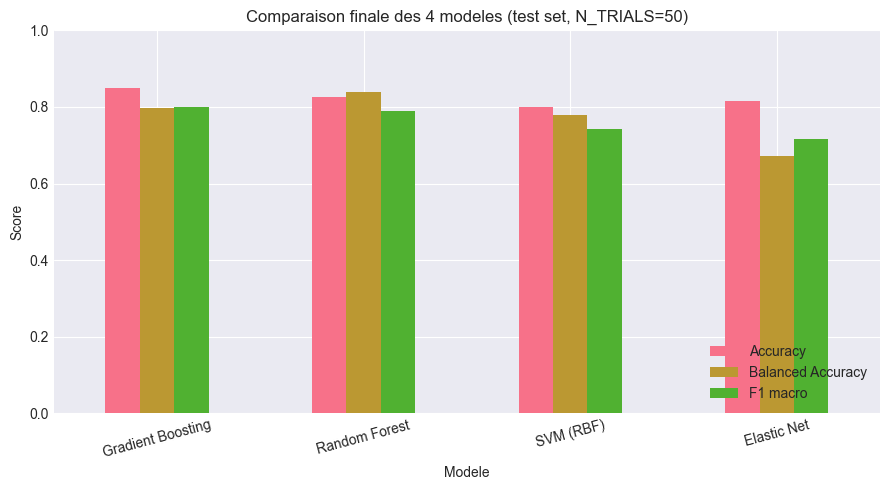

In [41]:
'''Visualisation comparative des 4 modeles sur les 3 metriques de reference.'''
fig, ax = plt.subplots(figsize=(9, 5))
df_plot = df_comparison.set_index("Modele")
df_plot.plot(kind="bar", ax=ax)
ax.set_title("Comparaison finale des 4 modeles (test set, N_TRIALS=50)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Interpretation a completer.**

## 11. Evaluation detaillee du modele retenu

Cette section reprend les diagnostics standardises dans tous les notebooks du pipeline, pour le
seul modele retenu en section 10.

### 11.1 Courbe d'apprentissage et diagnostic de surapprentissage

Calcule sur l'integralite du train set, sauf si le modele retenu est le SVM (qui reste sur le
sous-echantillon partage `X_train_sample`, seul modele de ce notebook avec une contrainte de
cout de calcul).

In [42]:
'''
Selectionne les donnees adaptees au modele retenu : le sous-echantillon partage uniquement
pour le SVM (cout de calcul eleve), l'integralite du train set pour les 3 autres modeles.
'''
if BEST_MODEL_NAME == "SVM (RBF)":
    X_for_eval, y_for_eval = X_train_sample, y_train_sample
else:
    X_for_eval, y_for_eval = X_train, y_train

print(f"Donnees utilisees pour l'evaluation de {BEST_MODEL_NAME} : {X_for_eval.shape[0]:,} lignes")


Donnees utilisees pour l'evaluation de Gradient Boosting : 44,285 lignes


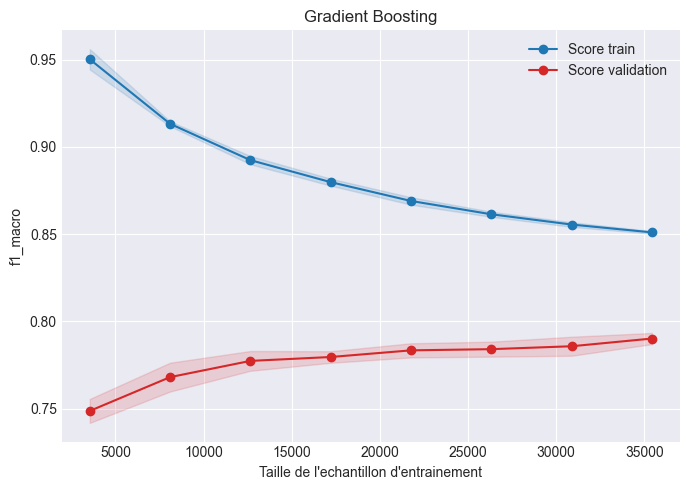

In [43]:
def plot_learning_curve(model, X, y, title, ax, cv=cv5, scoring="f1_macro"):
    '''Calcule et trace la courbe d'apprentissage d'un modele deja configure.'''
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=RANDOM_STATE,
    )
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", label="Score train", color="#1f77b4")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#1f77b4")
    ax.plot(train_sizes, val_mean, "o-", label="Score validation", color="#d62728")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#d62728")
    ax.set_title(title)
    ax.set_xlabel("Taille de l'echantillon d'entrainement")
    ax.set_ylabel(scoring)
    ax.legend(loc="best")


fig, ax = plt.subplots(figsize=(7, 5))
plot_learning_curve(best_model, X_for_eval, y_for_eval, BEST_MODEL_NAME, ax)
plt.tight_layout()
plt.show()


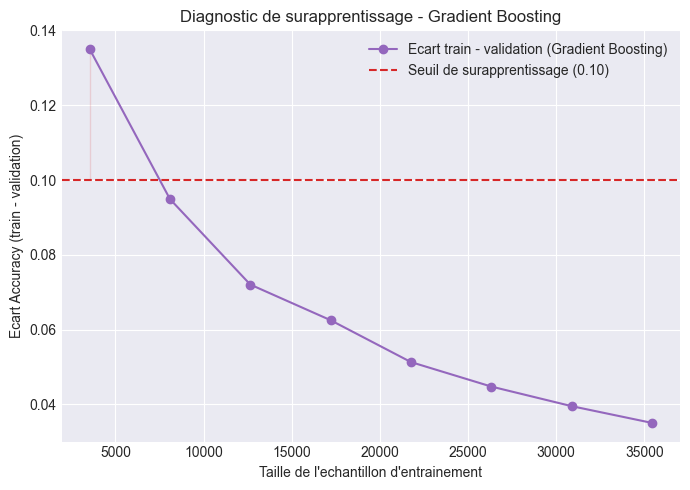

In [44]:
'''
Diagnostic de surapprentissage base sur l'accuracy, pour le modele retenu. Seuil de
surapprentissage fixe arbitrairement a 0.10.
'''
SEUIL_OVERFITTING = 0.10

train_sizes_acc, train_scores_acc, val_scores_acc = learning_curve(
    best_model, X_for_eval, y_for_eval,
    cv=cv5, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=RANDOM_STATE,
)
ecart_train_val_acc = train_scores_acc.mean(axis=1) - val_scores_acc.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes_acc, ecart_train_val_acc, "o-", color="#9467bd",
        label=f"Ecart train - validation ({BEST_MODEL_NAME})")
ax.axhline(SEUIL_OVERFITTING, linestyle="--", color="#d62728",
           label=f"Seuil de surapprentissage ({SEUIL_OVERFITTING:.2f})")
ax.fill_between(train_sizes_acc, ecart_train_val_acc, SEUIL_OVERFITTING,
                where=(ecart_train_val_acc > SEUIL_OVERFITTING), color="#d62728", alpha=0.15)
ax.set_xlabel("Taille de l'echantillon d'entrainement")
ax.set_ylabel("Ecart Accuracy (train - validation)")
ax.set_title(f"Diagnostic de surapprentissage - {BEST_MODEL_NAME}")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Sur la courbe d'apprentissage en F1 macro, on retrouve le meme ecart marque entre train et
validation que dans le notebook Boosting individuel (train autour de 0,85-0,95, validation
autour de 0,75-0,79), donc Gradient Boosting continue de sur-apprendre sur ce probleme. Par
contre, en accuracy, le diagnostic de surapprentissage est plutot encourageant : l'ecart
redescend sous le seuil de 0,10 a partir de 8000 lignes environ, et continue a diminuer jusqu'a
0,035 avec l'echantillon complet. Donc le sur-apprentissage existe bien mais reste modere une
fois qu'on a suffisamment de donnees, et il est moins marque que ce qu'on avait observe dans le
notebook Boosting individuel sur le meme diagnostic.



       Accuracy  F1 macro
Train  0.876572  0.848977
Test   0.850253  0.798632

Ecart Accuracy (train - test) : 0.026
Ecart F1 macro  (train - test) : 0.050


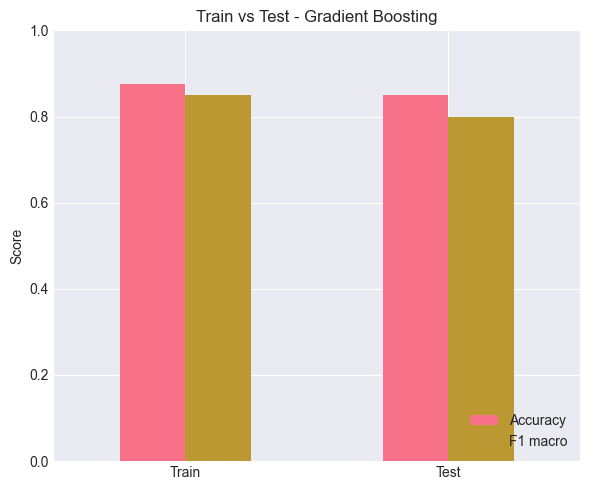

In [51]:
'''
Diagnostic final de surapprentissage : compare le score du modele retenu sur le train set
complet et sur le test set, jamais vu pendant l'entrainement ni l'optimisation Optuna. C'est
la verification la plus directe de la capacite de generalisation du modele, plus fiable que
la validation croisee (section 11.1) puisque le test set est totalement independant du
processus d'entrainement.
'''
y_pred_train_final = best_model.predict(X_train)
y_pred_test_final = best_model.predict(X_test)

scores_train_test = pd.DataFrame({
    "Train": {
        "Accuracy": accuracy_score(y_train, y_pred_train_final),
        "F1 macro": f1_score(y_train, y_pred_train_final, average="macro"),
    },
    "Test": {
        "Accuracy": accuracy_score(y_test, y_pred_test_final),
        "F1 macro": f1_score(y_test, y_pred_test_final, average="macro"),
    },
}).T

print(scores_train_test)
print()
ecart_acc = scores_train_test.loc["Train", "Accuracy"] - scores_train_test.loc["Test", "Accuracy"]
ecart_f1 = scores_train_test.loc["Train", "F1 macro"] - scores_train_test.loc["Test", "F1 macro"]
print(f"Ecart Accuracy (train - test) : {ecart_acc:.3f}")
print(f"Ecart F1 macro  (train - test) : {ecart_f1:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
scores_train_test.plot(kind="bar", ax=ax)
ax.set_title(f"Train vs Test - {BEST_MODEL_NAME}")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 11.2 Matrice de confusion

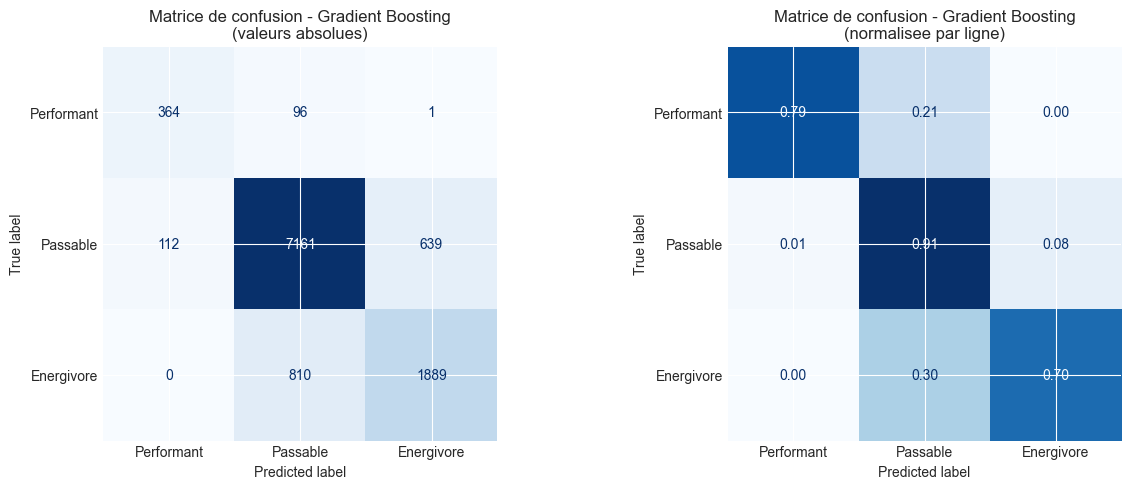

In [45]:
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_best, labels=GROUPS)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GROUPS)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Matrice de confusion - {BEST_MODEL_NAME}\n(valeurs absolues)")

cm_norm = confusion_matrix(y_test, y_pred_best, labels=GROUPS, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=GROUPS)
disp_norm.plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title(f"Matrice de confusion - {BEST_MODEL_NAME}\n(normalisee par ligne)")

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On obtient un tres bon rappel sur Performant (0,79) et Passable (0,91), ce qui represente une
nette amelioration par rapport au notebook Boosting individuel. Energivore reste la classe la
plus difficile (0,70 de rappel), avec ses erreurs qui se dirigent presque uniquement vers
Passable. Comme dans tous les notebooks precedents, on ne voit jamais de confusion directe entre
Performant et Energivore.

### 11.3 Rapport de classification

In [46]:
print(f"Rapport de classification - {BEST_MODEL_NAME}\n")
print(classification_report(y_test, y_pred_best, target_names=GROUPS, digits=3))


Rapport de classification - Gradient Boosting

              precision    recall  f1-score   support

  Performant      0.747     0.700     0.723      2699
    Passable      0.888     0.905     0.896      7912
  Energivore      0.765     0.790     0.777       461

    accuracy                          0.850     11072
   macro avg      0.800     0.798     0.799     11072
weighted avg      0.848     0.850     0.849     11072



#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le F1 macro de 0,799 est porte par un bon equilibre entre les 3 classes : Performant (F1 0,723),
Passable (F1 0,896, la plus solide) et Energivore (F1 0,777). Par rapport au Gradient Boosting du
notebook individuel (F1 macro 0,780), c'est une amelioration sur toutes les classes, en
particulier sur Performant (0,723 contre 0,665 precedemment).

### 11.4 Courbes ROC et Precision-Rappel (one-vs-rest)

Les colonnes de `predict_proba` sont reordonnees selon l'ordre de `GROUPS`, car scikit-learn
trie les classes alphabetiquement, ce qui ne correspond pas necessairement a l'ordre attendu.

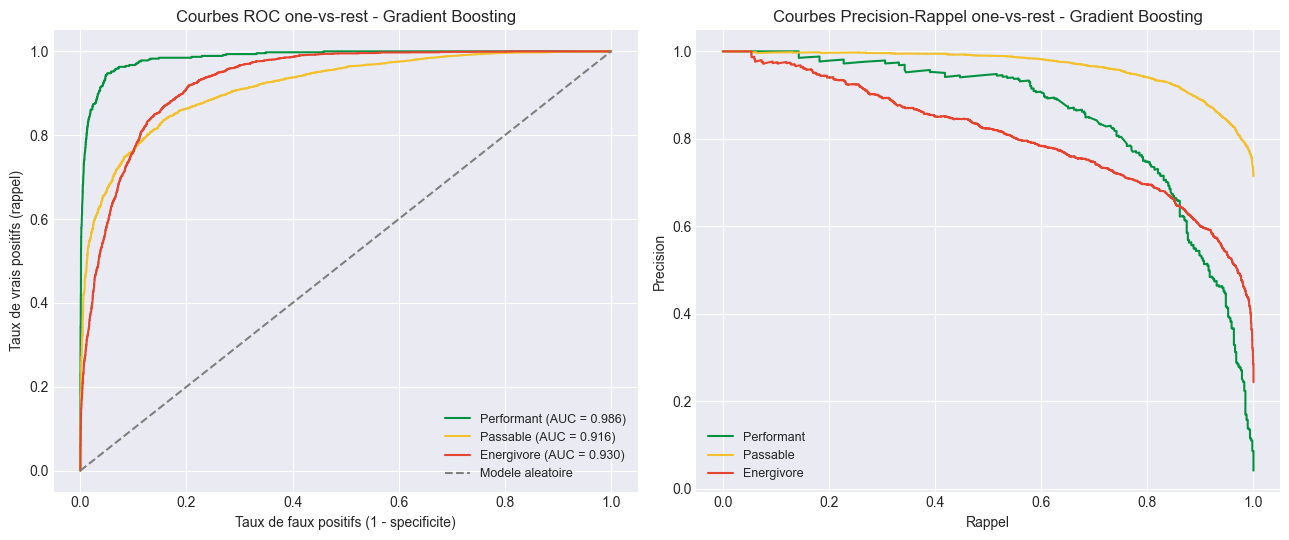

In [47]:
y_test_bin = label_binarize(y_test, classes=GROUPS)

y_proba_raw = best_model.predict_proba(X_test)
class_order = list(best_model.classes_)
reorder_idx = [class_order.index(grp) for grp in GROUPS]
y_proba_best = y_proba_raw[:, reorder_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for i, grp in enumerate(GROUPS):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=GROUP_COLORS[grp], label=f"{grp} (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modele aleatoire")
axes[0].set_xlabel("Taux de faux positifs (1 - specificite)")
axes[0].set_ylabel("Taux de vrais positifs (rappel)")
axes[0].set_title(f"Courbes ROC one-vs-rest - {BEST_MODEL_NAME}")
axes[0].legend(loc="lower right", fontsize=9)

for i, grp in enumerate(GROUPS):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_best[:, i])
    axes[1].plot(recall, precision, color=GROUP_COLORS[grp], label=grp)
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Courbes Precision-Rappel one-vs-rest - {BEST_MODEL_NAME}")
axes[1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Performant ressort encore une fois avec la meilleure AUC (0,986), devant Energivore (0,930) et
Passable (0,916) — le meme phenomene que dans les autres notebooks ou l'AUC ne reflete pas
directement le F1-score, puisque Performant est tres bien separable en probabilite mais son
seuil de decision par defaut n'est pas optimal pour cette classe minoritaire. Sur les courbes
Precision-Rappel, Passable reste la plus stable sur toute la plage de rappel, alors que
Performant et Energivore chutent plus vite a partir d'un rappel de 0,7-0,8.

## 12. Conclusion

Apres avoir reoptimise les 4 meilleurs modeles de chaque famille avec un budget Optuna plus
large (N_TRIALS=50) et un entrainement sur l'integralite du train set (sauf pour le SVM, limite
a 8000 lignes pour des raisons de cout de calcul), c'est **Gradient Boosting** qui se distingue
comme le modele final retenu pour le projet, avec un F1 macro de 0,799 sur le test set.

Le classement a legerement changé par rapport aux notebooks individuels (N_TRIALS=25), ou
Random Forest etait devant (0,788 contre 0,780 pour Gradient Boosting). Avec un budget Optuna
plus large, Gradient Boosting a fini par le depasser (0,799 contre 0,790), ce qui montre que le
gain venait surtout d'une meilleure exploration des hyperparametres plutot que d'un changement
de classement fondamental entre les familles de modeles : Random Forest et Gradient Boosting
restent les deux meilleures options, largement devant le SVM (0,743) et la regression logistique
(0,715).

Comme dans tous les notebooks precedents, Passable reste la classe la plus simple a predire,
Energivore la plus fragile, et il n'y a jamais de confusion directe entre Performant et
Energivore : les erreurs passent systematiquement par la classe intermediaire, ce qui confirme
la structure ordinale du probleme.

Le modele retenu sur-apprend encore un peu (ecart train-validation visible en F1 macro), mais
ce sur-apprentissage reste modere et se resorbe bien en accuracy une fois suffisamment de
donnees disponibles.

Comme limites generales du pipeline, on peut citer le sous-echantillonnage a 8000 lignes
necessaire pour le SVM (qui limite la comparaison stricte entre les 4 modeles sur les memes
donnees), l'absence de calibration des probabilites, et le fait que ce notebook ne constitue
qu'une etape de selection : un travail plus fin sur les hyperparametres de Gradient Boosting
(notamment max_depth, qui semble etre le principal responsable du sur-apprentissage observe)
pourrait encore ameliorer la generalisation du modele final.
```